>> 6장 : 인공 신경망 모델 기초

In [3]:
#[실습 06-01]

!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import random
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#[실습 06-02]

# 데이터 직접 생성
# 입력 타깃 간 복잡한 비선형 관계를 갖는 데이터 생성

np.random.seed(0)       # 랜덤 시드 고정

n = 1000

x1 = np.random.uniform(-3,3,n)
x2 = np.random.uniform(-3,3,n)
# -3에서 3 범위의 n개의 실수를 무작위 추출
# n이 1000이므로 변수 x1, x2는 각각 1000개의 값을 가짐

# 타깃 생성
y = np.sin(x1) * np.log(x2 ** 2) + np.exp(-x1**2 - x2**2)

print("x1 :",x1[:5])
print("x2 :",x2[:5])
print("y :",y[:5])

x1 : [ 0.29288102  1.2911362   0.61658026  0.2692991  -0.4580712 ]
x2 : [ 0.55728162 -2.93961783 -0.14504282  1.25262235 -2.73614741]
y : [ 0.33516589  2.0728087  -1.56336879  0.31352531 -0.88977731]


In [ ]:
#[실습 06-03]

# 입력과 타깃 변수 지정
X = np.stack((x1,x2),axis = 1)      # 입력
# x1과 x2를 열 방향으로 이어 붙여 (1000,2) 형태의 입력 행렬 X 생성
y = np.array(y).reshape(-1,1)       # 타깃
# reshape(-1,1)로 y를 (1000,1) 형태의 타깃 행렬로 변환

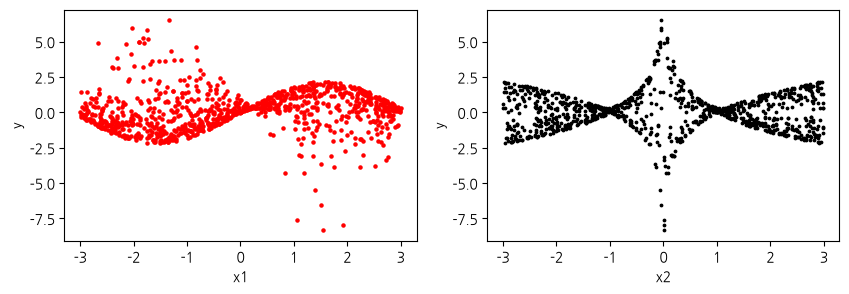

In [8]:
#[실습 06-04]

# 산점도 그려 탐색적 데이터 분석 진행

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.scatter(X[:,0],y,s=5,color="r") #s는 점의 크기 조절 옵션
plt.xlabel('x1')
plt.ylabel('y')

plt.subplot(1,2,2)
plt.scatter(X[:,1],y,s=3,color="k") #s는 점의 크기 조절 옵션
plt.xlabel('x2')
plt.ylabel('y')

plt.show()

>> x1과 x2 모두 y와 비선형 관게를 가짐
>> 직선으로는 관계를 설명할 수 없음
>> 비선형 패턴 활용이 가능한 ANN 모델이 더 적합!

In [9]:
#[실습 06-05]
# 선형회귀모델 적용

model = LinearRegression()
model.fit(X,y)

print("가중치(weights) =",model.coef_)
print("편향(bias) =",model.intercept_)
print()

y_pred = model.predict(X)

MSE = mean_squared_error(y,y_pred)
print("평균제곱오차 =",MSE)

acc = r2_score(y,y_pred)
print("R-제곱 =",acc)

가중치(weights) = [0.09877415 0.00971141]
편향(bias) = 0.08475303608373772

평균제곱오차 = 2.016670831773134
R-제곱 = 0.014657923483553659


>> R² 값이 매우 작음(0.014) 
>> 선형회귀모델은 비선형 관계를 거의 설명하지 못한다

>> {{인공 신경망 모델 설정}}

행렬 곱이 정의되려면 가중치 행렬의 형태(shape)가 (이전 층 유닛 수, 현재 층 유닛 수)여야 한다
전체 파라미터 수
    = 층과 층 사이를 연결하는 가중치와 편향의 개수를 모두 합한 값

인공 신경망 모델은 입력층, 은닉층, 출력층을 차례로 정의해 서로 연결하여 하나의 모델을 구성

In [ ]:
#[실습 06-06]

# 함수 기반 (Function API) 설정
# 모델의 벡터 변환 과정을 함수 형태로 명시

#입력
x = Input(shape=(2,))           # shape에 주의, 입력층 정의, 2는 입력 변수의 수
# x = Input(shape=X[0].shape)   # shape 자동 설정, 위의 코드랑 동일하나 더 간단하게 설정

#선형 변환
z = Dense(units=2)(x)           # x를 입력으로 받아 은닉층 생성
q = Dense(units=2)(z)
y_pred = Dense(units=1)(q)      # 출력층 정의

#모델 설정
my_model = Model(inputs = x, outputs = y_pred)  # 입력으로 출력을 연결
my_model.summary()              # 모델 구조 요약(표 형태로 출력)

# 모델의 구조를 명확하게 표현할 수 있으나 복잡

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
#[실습 06-07]

# 단계적(Sequential) 설정

model = Sequential([
    Input(shape=X[0].shape),
    Dense(2),                   # units는 생략 가능
    Dense(2),
    Dense(1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

>> 활성화 함수(Activation Function)을 사용하면 비선형 관계도 학습이 가능
>> 가장 널리 쓰이는 함수는 ReLU

In [ ]:
#[실습 06-08]

# 모든 은닉층에 ReLU 함수를 적용하여 기존 모델 수정

model = Sequential([
    Input(shape=X[0].shape),
        Dense(2,activation='relu'),                   # units는 생략 가능
        Dense(2,activation='relu'),
        Dense(1,activation='linear')
])

# 회귀 문제에서는 타깃 예측값이 음수나 양수 등 모든 실수값을 가질 수 있음
# 출력층에는 활성화 함수를 적용하지 않는다
# activation = linear는 기본값이므로 생략해도 같은 결과가 나옴

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

>> 위의 회귀 문제가 아니라 분류 문제라면 클래스가 될 확률을 예측해야 하므로,
>> 출력층의 값을 클래스별 확률로 변환하는 활성화 함수가 필요

>> 이떄 사용하는 함수가 Softmax 함수
>> 실수를 0과 1 사이의 확률로 변환하고 모든 클래스의 확률 합이 1이 되도록 한다

>> {인공 신경망 모델 학습}

>> 용어 / 학습 과정

Batch : 모델이 파라미터를 한 번 업데이트할 때 사용하는 데이터의 묶음
Mini-Batch : 데이터를 작은 묶음으로 쪼개 학습하는 방식
             ANN에서 사용
            (1) 메모리의 용량 제한
            (2) 일반화 성능을 높이기 위해

Epoch : 모든 미니배치에 대한 학습이 완료되어 전체 데이터가 모델을 한 번 통과(학습)하는 과정
        에포크가 반복되어도 동일순서x, 매번 다른 데이터 조합으로 학습이 이루어짐
        모델은 각 미니배치마다 예측 -> 손실계산 -> 파라미터 업데이트 수행
        하나의 에포크가 끝나면 전체 미니배치의 평균 손실 출력

In [16]:
#[실습 06-09]

# 랜던 시드 고정

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

컴파일 :  모델이 사용할 손실함수와 최적화도구(optimizer)를 설정하는 과정
        모델 구성을 모두 마친 후 실행해야 한다

In [ ]:
#[실습 06-10]

# 컴파일

model.compile(loss="mse",optimizer="adam")
# 손실 함수는 MSE(평균제곱오차)
# 최적화 도구는 adam(Adaptive Moment Estimation)
#   : 과거 gradient 정보를 같이 참고해서 가중치를 업데이트
#     경사하강법 한계 개선
#     기본 학습률 0.001

In [ ]:
# 필요에 따라 컴파일 코드를 다믕과 같이 변경해 학습률을 직접 지정할 수 있다

# 라이브러리 불러오기
# from tensorflow.keras.optimizers import Adam

# 학습률 변경
# model.compile(
#     loss= "mse", optimizer = Adam(learning_rate = 0.0005)      # 학습률 직접 지정 가능
# )

In [20]:
#[실습 06-11]

# 모델 학습
model.fit(X,y,epochs=300, batch_size=32)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 2.3921 
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 2.2738
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 2.2018
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - loss: 2.1549
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 2.1222
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 2.0981
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 2.0801
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 2.0663
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 2.0560
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - loss: 2.0484
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - loss: 2.0427
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - loss: 2.0382
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - loss: 2.0347
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - loss: 2.0320
Epoch 15/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s

>> epochs가 진행될수록 loss가 점차 감소

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step


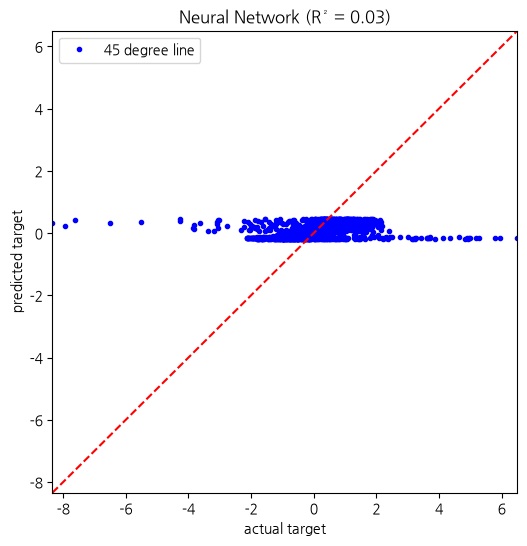

In [22]:
#[실습 06-12]

# 학습된 모델로 타깃값 예측, 예측 성능 시각화

y_pred = model.predict(X)       # 예측 수행
r2 = r2_score(y,y_pred)         # R² 계산

plt.figure(figsize=(6,6))
plt.plot(y,y_pred,"b.",label = "45 degree line")
plt.axis([min(y),max(y),min(y),max(y)])
plt.plot([min(y),max(y)],[min(y),max(y)],ls="--",c="r")
plt.xlabel("actual target")
plt.ylabel("predicted target")
plt.title(f"Neural Network (R² = {r2:.2f})")
plt.legend()
plt.show()

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9313   
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 1.7342
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - loss: 1.5270
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 1.2906
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - loss: 1.0508
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step - loss: 0.8565
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.7342
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 0.6655
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 0.6182
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - loss: 0.5859
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - loss: 0.5583
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - loss: 0.5341
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 0.5134
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - loss: 0.4960
Epoch 15/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s

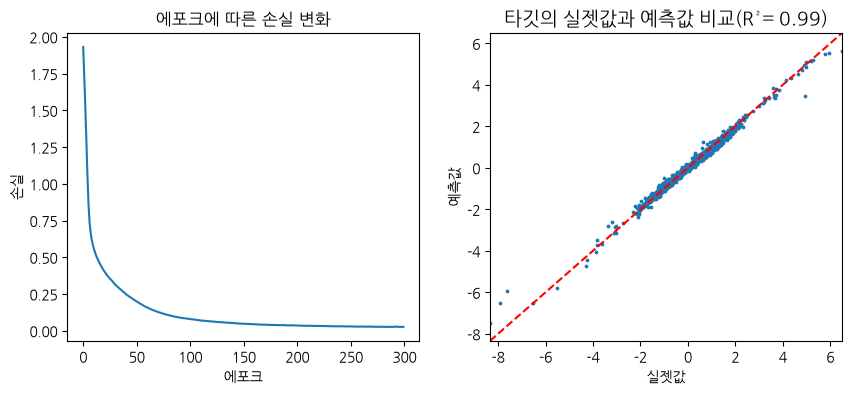

In [23]:
#[실습 06-13]

# 은닉층을 3개, 각 은닉층의 유닛 수를 16으로 늘린다
# 하이퍼파라미터 : 모델의 구조와 학습 방식에 영향을 주지만, 자동으로 최적화되지 않고 학습 전에 직접 설정하는 값
# 튜닝 : 하이퍼파라미터 설정 시 여러 값을 시도해 보면서 가장 좋은 성능을 내는 조합 찾는 과정

# 랜덤 시드 고정
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 신경망 모형 재설정(유닛 증가. 은닉층 추가)
model=Sequential([
    Input(shape=X[0].shape),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),  # 3번 은닉층
    Dense(1)    ])

model.compile(optimizer="adam", loss="mse")

history=model.fit(X, y, epochs=300)
#학습 결과를 history 객체로 저장하면, 학습 과정에서 계산된 손실과 같은 주요 정보를 함께 저장

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel('에포크')
plt.ylabel('손실')
plt.title('에포크에 따른 손실 변화')

plt.subplot(1, 2, 2)
y_pred = model.predict(X) # 타깃 예측
r2=r2_score(y, y_pred)    # R제곱 계산
plt.scatter(y, y_pred, s=3)
plt.axis([min(y), max(y), min(y), max(y)])
plt.plot([min(y), max(y)], [min(y), max(y)], ls="--", c="r")
plt.title(f'타깃의 실젯값과 예측값 비교(R²= {r2:.2f})', fontsize=14)
plt.xlabel('실젯값'); plt.ylabel('예측값');
plt.show()

In [24]:
#[실습 06-14]

# 새로운 입력에 대한 타깃을 예측

x_new = np.array([[-0.5,0.2]])  # 새로운 입력

print("새로운 입력",x_new, "에 대한")
print("타깃의 예측값은",model.predict(x_new),"입니다")

새로운 입력 [[-0.5  0.2]] 에 대한
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
타깃의 예측값은 [[2.316135]] 입니다


>> 포물선.csv에는 입력과 타깃 데이터로 구성된 1000개의 데이터가 저장되어 있다

       target   feature
0   -0.232359  0.000000
1   -0.244998  0.001001
2   -0.238215  0.002002
3   -0.224597  0.003003
4   -0.227336  0.004004
..        ...       ...
995 -0.241883  0.995996
996 -0.248990  0.996997
997 -0.247060  0.997998
998 -0.260476  0.998999
999 -0.253581  1.000000

[1000 rows x 2 columns]



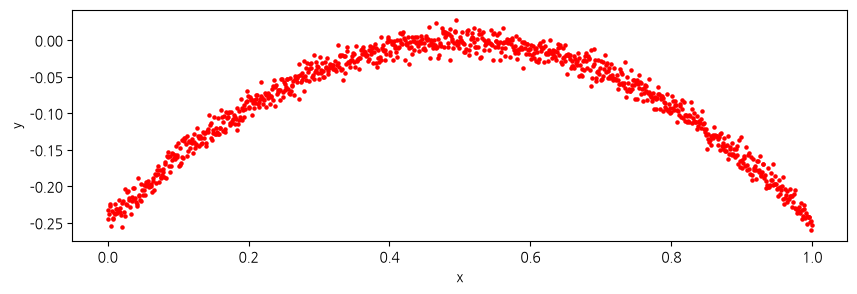

In [31]:
#되새김_6장_Q1

# 데이터를 불러온 후, 입력과 타깃 간의 관계를 산점도로 시각화

!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import random
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings('ignore')


# 데이터 불러오기
df = pd.read_csv("포물선.csv", encoding='cp949')
print(df)
print()

# 입력과 타깃 변수 지정
x = np.array(df['feature'])
y = np.array(df['target'])

# 산점도 그려 탐색적 데이터 분석 진행

plt.figure(figsize=(10,3))
plt.scatter(x,y,s=5,color="r") #s는 점의 크기 조절 옵션
plt.xlabel('x')
plt.ylabel('y')

plt.show()


In [36]:
#되새김_6장_Q2

# 은닉층이 2개인 인공 신경망 모델 구성
# 각 은닉층에는 유닛 10개를 사용, 활성화 함수는 모두 ReLU 사용

!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import random
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings('ignore')

# 랜덤 시드 고정(모델 설정 전에 실행)
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 신경망 모형
model=Sequential([
    Input(shape=(1,)),
        Dense(10,activation='relu'),                   # units는 생략 가능
        Dense(10,activation='relu'),
        Dense(1,activation='linear')
])

# 회귀 문제에서는 타깃 예측값이 음수나 양수 등 모든 실수값을 가질 수 있음
# 출력층에는 활성화 함수를 적용하지 않는다
# activation = linear는 기본값이므로 생략해도 같은 결과가 나옴

model.summary()
model.compile(loss="mse",optimizer="adam")
model.fit(x,y,epochs=300, batch_size=32)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - loss: 0.0063 
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 0.0053
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 0.0046
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 0.0040
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 0.0034
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - loss: 0.0028
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.0023
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 0.0019
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 0.0013
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - loss: 0.0011
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - loss: 9.0486e-04
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step - loss: 7.7514e-04
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step - loss: 6.7116e-04
Epoch 15/300
32/32 ━━━━━━━━━━━━━

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 649us/step - loss: 0.0063 
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.0053
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 0.0046
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 0.0040
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - loss: 0.0034
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 0.0028
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.0023
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0019
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 0.0016
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - loss: 0.0013
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 0.0011
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 9.0486e-04
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 7.7514e-04
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 6.7116e-04
Epoch 15/300
32/32 ━━━━━━━━━━━

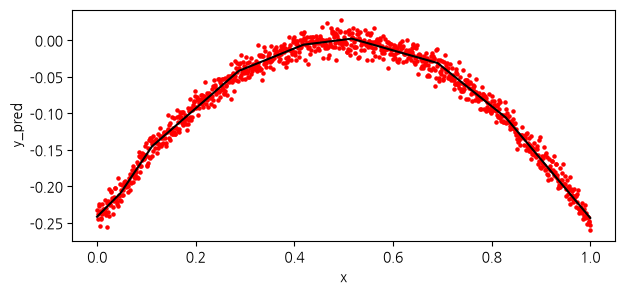

In [47]:
#되새김_6장_Q3

# 모델을 학습한 뒤, 실젯값과 예측값을 비교해 예측 정확도를 시각화

!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import random
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings('ignore')

# 랜덤 시드 고정(모델 설정 전에 실행)
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 신경망 모형
model=Sequential([
    Input(shape=(1,)),
        Dense(10,activation='relu'),                   # units는 생략 가능
        Dense(10,activation='relu'),
        Dense(1,activation='linear')
])

# 회귀 문제에서는 타깃 예측값이 음수나 양수 등 모든 실수값을 가질 수 있음
# 출력층에는 활성화 함수를 적용하지 않는다
# activation = linear는 기본값이므로 생략해도 같은 결과가 나옴

model.compile(loss="mse",optimizer="adam")
model.fit(x,y,epochs=300, batch_size=32)


# 타겟 예측 및 R제곱 계산
y_pred = model.predict(x)
r2 = r2_score(y, y_pred)


# 산점도 그려 탐색적 데이터 분석 진행

plt.figure(figsize=(7,3))
plt.scatter(x,y,s=5,color="r") #s는 점의 크기 조절 옵션
plt.plot(x, y_pred, "k", label='모델 예측')
plt.xlabel('x')
plt.ylabel('y_pred')

plt.show()